In [ ]:
!pip install -U transformers # Installer le paquet HuggingFace Transformers
import torch

In [ ]:
from huggingface_hub import login
login(token="",new_session=False)

Nous allons télécharger le modèle situé sur cette page : https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct

Si vous n'avez jamais utilisé ce modèle auparavant, vous verrez peut-être une invite sur la page ci-dessus : « You need to agree to share your contact information to access this model ». En effet, l'utilisation du modèle Llama nécessite la signature d'un accord d'utilisation (tous les modèles ne nécessitent pas la signature d'un accord). Veuillez suivre les instructions sur la page pour signer. Après cela, vous recevrez un e-mail de notification vous informant si l'examen est approuvé. Vous ne pourrez commencer à l'utiliser qu'après approbation. Ce processus peut parfois prendre plusieurs heures. Pour plus de détails, veuillez vous référer aux diapositives de l'assistant.

Après avoir exécuté le code suivant, nous téléchargerons deux objets, le tokenizer et le modèle, depuis le Hugging Face Hub. Le tokenizer enregistre les tokens utilisés par le modèle, tandis que le modèle stocke les paramètres du modèle. Le processus de téléchargement peut prendre plusieurs minutes, veuillez patienter.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Nous téléchargeons également le modèle situé sur cette page : https://huggingface.co/google/gemma-3-4b-it

In [ ]:
#tokenizer2 = AutoTokenizer.from_pretrained("google/gemma-3-4b-it")
#model2 = AutoModelForCausalLM.from_pretrained("google/gemma-3-4b-it")
# Si vous êtes un utilisateur gratuit de Colab et que vous ne pouvez pas exécuter le deuxième modèle, veuillez commenter ce bloc.

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

# Voyons ce qu'il y a dans le modèle

Regardons d'abord combien de paramètres le modèle que nous avons chargé possède au total. `model` est Llama-3.2-3B-Instruct et `model2` est google/gemma-3-4b-it.

``model.num_parameters()`` nous donnera le nombre de paramètres du ``model``.

In [ ]:
model.num_parameters() # Voyons le nombre de paramètres du modèle (meta-llama/Llama-3.2-3B-Instruct)

1235814400

In [ ]:
#model2.num_parameters() # Voyons le nombre de paramètres du modèle2 (google/gemma-3-4b-it)

4300079472

Les paramètres des modèles d'apprentissage profond sont généralement stockés sous forme de plusieurs matrices et vecteurs (les vecteurs, matrices, etc. sont collectivement appelés tenseurs (Tensor)).

Dans le modèle, chaque tenseur contenant des paramètres possède les informations suivantes dans `model` :

- **Nom (name)** : Indique la position du paramètre dans la structure du modèle, par exemple `model.layers.0.mlp.up_proj.weight`, qui est le paramètre de la première couche MLP dans la première couche de transformateur.
- **Forme (shape)** : Indique la dimension du tenseur, par exemple `(8192, 3072)`, ce qui signifie qu'il s'agit d'une matrice, dont une dimension est 8192 et l'autre est 3072.

Nous pouvons utiliser la méthode `named_parameters()` pour visualiser ces paramètres un par un.

In [ ]:
for name, param in model.named_parameters():
    print(f"{name:80}  |  shape: {tuple(param.shape)}")

# D'après la sortie, combien de couches possède Llama-3.2-1B-Instruct ?

model.embed_tokens.weight                                                         |  shape: (128256, 2048)
model.layers.0.self_attn.q_proj.weight                                            |  shape: (2048, 2048)
model.layers.0.self_attn.k_proj.weight                                            |  shape: (512, 2048)
model.layers.0.self_attn.v_proj.weight                                            |  shape: (512, 2048)
model.layers.0.self_attn.o_proj.weight                                            |  shape: (2048, 2048)
model.layers.0.mlp.gate_proj.weight                                               |  shape: (8192, 2048)
model.layers.0.mlp.up_proj.weight                                                 |  shape: (8192, 2048)
model.layers.0.mlp.down_proj.weight                                               |  shape: (2048, 8192)
model.layers.0.input_layernorm.weight                                             |  shape: (2048,)
model.layers.0.post_attention_layernorm.weight              

In [ ]:
#for name, param in model2.named_parameters():
#    print(f"{name:80}  |  shape: {tuple(param.shape)}")

# Comparez, quelles sont les différences entre le modèle (Llama-3.2-3B-Instruct) et le modèle 2 (google/gemma-3-4b-it) ?

Utilisez `model.state_dict()` pour extraire et visualiser les paramètres.

In [ ]:
model.state_dict()

OrderedDict([('model.embed_tokens.weight',
              tensor([[ 3.1281e-03,  1.7822e-02,  2.0996e-02,  ..., -5.2185e-03,
                       -4.1992e-02, -3.3447e-02],
                      [ 2.3682e-02, -2.2949e-02,  1.9897e-02,  ..., -9.4604e-03,
                       -2.2125e-03, -3.9551e-02],
                      [ 1.4465e-02,  1.0559e-02,  9.8267e-03,  ...,  6.8359e-03,
                       -1.1597e-02,  5.7983e-03],
                      ...,
                      [-1.0580e-06,  1.0620e-02, -1.9043e-02,  ...,  1.3885e-03,
                       -1.7700e-03,  9.7046e-03],
                      [-1.3635e-06,  1.0620e-02, -1.9043e-02,  ...,  1.3885e-03,
                       -1.7700e-03,  9.7046e-03],
                      [-1.1921e-06,  1.0620e-02, -1.9043e-02,  ...,  1.3885e-03,
                       -1.7700e-03,  9.7046e-03]])),
             ('model.layers.0.self_attn.q_proj.weight',
              tensor([[-0.0179,  0.0066,  0.0247,  ..., -0.0087, -0.0117,  0.0201],
 

[[-0.03930664 -0.01928711 -0.02258301 ...  0.01397705 -0.02441406
  -0.03125   ]
 [ 0.01293945 -0.00257874 -0.01000977 ...  0.01794434 -0.02197266
   0.03466797]
 [-0.02026367 -0.0402832   0.01190186 ... -0.02941895  0.00778198
  -0.02636719]
 ...
 [-0.01348877 -0.02026367  0.00302124 ...  0.01397705  0.0189209
  -0.01409912]
 [ 0.02758789  0.00286865  0.00567627 ...  0.01538086  0.03271484
   0.03271484]
 [ 0.00106049  0.01708984 -0.01177979 ...  0.00442505 -0.0067749
  -0.02685547]]


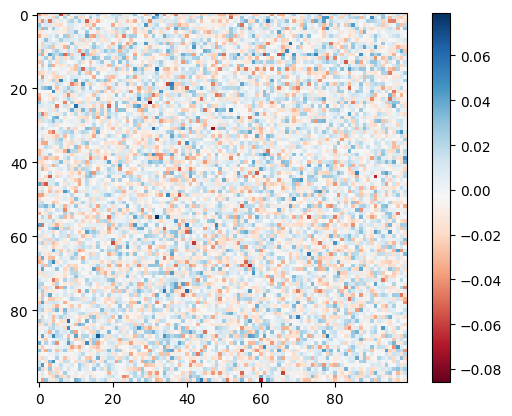

In [ ]:
weight = model.state_dict()["model.layers.10.mlp.up_proj.weight"].numpy()

# Le code ci-dessus peut être divisé en trois étapes : 1. state_dict() 2. ["nom_paramètre"] 3. .numpy()
# La méthode model.state_dict() renvoie un dictionnaire (dict) dont la clé (key) est le nom du paramètre et la valeur (value) est un tenseur (Tensor).
# Vous pouvez utiliser [] pour obtenir la valeur correspondante en fonction de la clé.
# La valeur ici est un tenseur PyTorch, .numpy() convertira le tenseur en un tableau au format NumPy

print(weight)

# Dessiner la zone 100x100 en haut à gauche de weight
import matplotlib.pyplot as plt
plt.imshow(weight[:100, :100], cmap="RdBu")
plt.colorbar()
plt.show()

# On ne voit pas grand chose, n'est-ce pas...

## Observer la table d'embedding dans le modèle de langage

In [ ]:
# Extraire d'abord la table d'embedding du modèle

input_embedding = model.state_dict()["model.embed_tokens.weight"].numpy()

Regardons d'abord la forme (shape) de input_embedding.

In [ ]:
'''
Affichez la forme de input_embedding pour observer.

Vous verrez (128256, 3072), ce qui signifie que input_embedding est une matrice avec 128 256 lignes (row) et 3 072 colonnes (column).

- **128256** → Taille du vocabulaire, il y a 128 256 tokens différents.
- **3072** → Chaque token est représenté par un vecteur de dimension 3 072.

En d'autres termes, chaque ligne correspond à un token.
'''

print(input_embedding.shape)

(128256, 2048)


In [ ]:
# Afficher input_embedding pour observer
print(input_embedding)

# Hmm... on ne voit toujours pas grand chose

[[ 3.1280518e-03  1.7822266e-02  2.0996094e-02 ... -5.2185059e-03
  -4.1992188e-02 -3.3447266e-02]
 [ 2.3681641e-02 -2.2949219e-02  1.9897461e-02 ... -9.4604492e-03
  -2.2125244e-03 -3.9550781e-02]
 [ 1.4465332e-02  1.0559082e-02  9.8266602e-03 ...  6.8359375e-03
  -1.1596680e-02  5.7983398e-03]
 ...
 [-1.0579824e-06  1.0620117e-02 -1.9042969e-02 ...  1.3885498e-03
  -1.7700195e-03  9.7045898e-03]
 [-1.3634562e-06  1.0620117e-02 -1.9042969e-02 ...  1.3885498e-03
  -1.7700195e-03  9.7045898e-03]
 [-1.1920929e-06  1.0620117e-02 -1.9042969e-02 ...  1.3885498e-03
  -1.7700195e-03  9.7045898e-03]]


In [ ]:
# Le token avec l'ID token_id correspond à la ligne token_id de input_embedding (en comptant à partir de 0).
# Ci-dessous, nous affichons le token avec l'ID token_id ainsi que son embedding correspondant.

token_id = 2

# Obtenir le token (texte) correspondant au token_id depuis le tokenizer
token = tokenizer.decode(token_id)

# Obtenir le vecteur de ce token
embedding_vector = input_embedding[token_id]

print(f"Token ID: {token_id}")
print(f"Token correspondant: {token}")
print(f"Token Embedding: {embedding_vector}")

Token ID: 2
Token correspondant: #
Token Embedding: [ 0.01446533  0.01055908  0.00982666 ...  0.00683594 -0.01159668
  0.00579834]


Observer directement les valeurs d'embedding ne donne pas beaucoup d'informations. Cependant, nous pouvons calculer la similarité des embeddings entre les tokens.
Cela nous permet de savoir quels tokens ont des significations similaires pour ce modèle de langage.
Ce code nous permet de :
1. Entrer un token (par exemple `"apple"`)
2. Trouver son `token_id` (par exemple `"apple"`)
3. Obtenir son embedding à partir de `input_embedding` en utilisant le `token_id`
4. Utiliser la similarité cosinus pour calculer sa similarité d'embedding avec tous les autres tokens
5. Lister les `top_k` tokens les plus proches

In [ ]:
top_k = 20 # Définissez une valeur vous-même

# 1️⃣ Laisser l'utilisateur entrer un token
token = input('Veuillez entrer un token :') # Entrée : apple, Apple, Lee, Wang, etc.

# 2️⃣ Convertir en token ID
token_id = tokenizer.encode(token)[1]
# Pourquoi [1] ?
# tokenizer.encode() retourne : [BOS_token_id, token_id ...]
# print (tokenizer.encode(token)) <- Essayez d'exécuter cette ligne
# Le premier élément [0] est le symbole de début spécial (BOS),
# Ce que nous voulons vraiment, c'est le token entré lui-même → donc on prend l'index 1
print("L'ID du token est ", token_id)

# 3️⃣ Obtenir l'embedding du token
embbeding = [input_embedding[token_id]]

# 4️⃣ Calculer la similarité cosinus
from sklearn.metrics.pairwise import cosine_similarity
sims = cosine_similarity(embbeding, input_embedding)[0]

# 5️⃣ Trier et prendre les top_k les plus proches, et afficher le résultat
nearest = sims.argsort()[::-1][1: top_k+1] # Exclure soi-même
print(f'Les {top_k} tokens les plus proches de {token} :')
for idx in nearest:
  print(f'{tokenizer.decode(idx)} (score: {sims[idx]:.4f})')

Veuillez entrer un token :top model
L'ID du token est  3565
Les 20 tokens les plus proches de top model :
Top (score: 0.7268)
 top (score: 0.7181)
	top (score: 0.7119)
-top (score: 0.6975)
 Top (score: 0.6789)
_top (score: 0.6765)
TOP (score: 0.6440)
 TOP (score: 0.6249)
.top (score: 0.6232)
(top (score: 0.6076)
/top (score: 0.5675)
,top (score: 0.5508)
.Top (score: 0.5412)
_Top (score: 0.5278)
_TOP (score: 0.5149)
 tops (score: 0.4993)
=top (score: 0.4675)
[top (score: 0.4575)
 topo (score: 0.4405)
 Tops (score: 0.4351)


## Afficher la représentation de chaque couche

Extraire la représentation de chaque couche

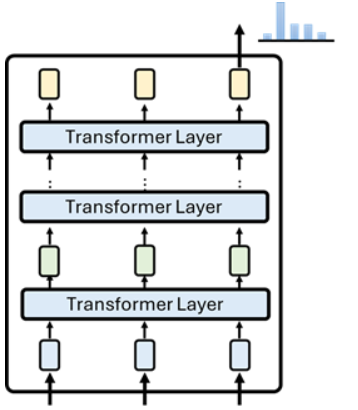


In [ ]:
inputs = tokenizer.encode("Bonjour , tous les mondes", return_tensors="pt")

print("Token IDs encodés :", inputs)

outputs = model(inputs, output_hidden_states=True) # output_hidden_states=True retournera la représentation de chaque couche (états cachés)

hidden_states = outputs.hidden_states
# hidden_states[0] -> embedding (le résultat de la conversion du token en embedding de token)
# hidden_states[1] ~ hidden_states[N] -> Sortie de chaque bloc Transformer
print(f"Au total {len(hidden_states)} couches de représentation obtenues (y compris l'embedding de token).")

# Lister la forme de sortie de chaque couche
for idx, h in enumerate(hidden_states):
    print(f"Forme de sortie de la couche {idx:2d} : {h.shape}")
    # h.shape = [batch_size, seq_len, hidden_size]
    # batch_size → Nombre de phrases traitées à la fois
    # sequence_length → En combien de tokens la phrase est découpée
    # hidden_size → Longueur du vecteur de chaque token


print("\n=== Sortie de Token Embedding ===")
print(hidden_states[0])

print("\n=== Sortie de la première couche Transformer ===")
print(hidden_states[1])

Token IDs encodés : tensor([[128000,  82681,   1174,  26725,   3625,   1647,   5919]])
Au total 17 couches de représentation obtenues (y compris l'embedding de token).
Forme de sortie de la couche  0 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  1 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  2 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  3 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  4 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  5 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  6 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  7 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  8 : torch.Size([1, 7, 2048])
Forme de sortie de la couche  9 : torch.Size([1, 7, 2048])
Forme de sortie de la couche 10 : torch.Size([1, 7, 2048])
Forme de sortie de la couche 11 : torch.Size([1, 7, 2048])
Forme de sortie de la couche 12 : torch.Size([1, 7, 2048])
Forme de sortie de la couche 13 : torch.Size([1, 7, 2048])
Forme 

Comparons les représentations pour différentes entrées

In [ ]:
def get_embedding(text, layer_num):
    """
    Entrez une phrase, imprimez l'embedding de chaque token d'une certaine couche du modèle.

    """
    print(f"\n=== {text} ===")

    inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=False)
    #print(inputs)

    outputs = model(inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states
    hidden_states_layer = hidden_states[layer_num]

    tokens = tokenizer.tokenize(text)
    seq_length = len(tokens)
    for t in range(0,seq_length):
      print(tokens[t], ":", hidden_states_layer[0][t])

layer_num = 10 # 0 : embedding de token, >0 : embedding de token contextuel
get_embedding("How about you?", layer_num )
get_embedding("How are you?", layer_num )
get_embedding("Nice to meet you.", layer_num )


=== How about you? ===
How : tensor([-0.0230,  0.0981,  0.1788,  ..., -0.0939, -0.0524,  0.0876],
       grad_fn=<SelectBackward0>)
Ġabout : tensor([-0.0248, -0.0692, -0.2249,  ...,  0.1951, -0.1054,  0.1698],
       grad_fn=<SelectBackward0>)
Ġyou : tensor([-0.1685,  0.0558, -0.1226,  ...,  0.0410,  0.1521,  0.0850],
       grad_fn=<SelectBackward0>)
? : tensor([-0.2427,  0.0101,  0.0130,  ..., -0.0910,  0.0295,  0.0137],
       grad_fn=<SelectBackward0>)

=== How are you? ===
How : tensor([-0.0230,  0.0981,  0.1788,  ..., -0.0939, -0.0524,  0.0876],
       grad_fn=<SelectBackward0>)
Ġare : tensor([-0.0595, -0.0550, -0.0939,  ..., -0.1044, -0.0904,  0.0538],
       grad_fn=<SelectBackward0>)
Ġyou : tensor([-0.1886, -0.1919,  0.0226,  ...,  0.0942, -0.0635,  0.1686],
       grad_fn=<SelectBackward0>)
? : tensor([-0.2078, -0.0463,  0.0513,  ..., -0.1653, -0.0566, -0.0393],
       grad_fn=<SelectBackward0>)

=== Nice to meet you. ===
Nice : tensor([-0.0618, -0.0529,  0.5550,  ..., -0.23

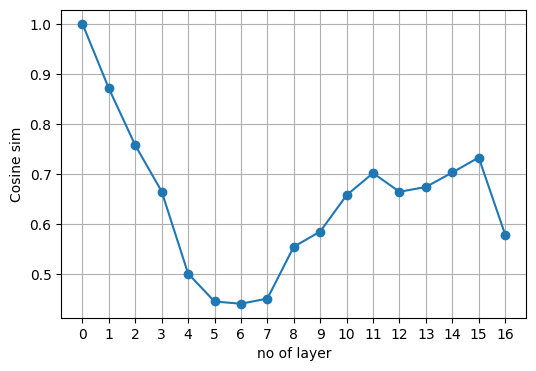

In [ ]:
# Comparer la similarité de "apple" dans sentence1 et sentence2 à différentes couches.

sentence1 = "I ate an apple for breakfast."
idx1 = 4 # Position de apple dans "I ate an apple for breakfast."
#[128000, 40, 30912, 459, 24149, 369, 17954, 13]
sentence2 = "The company that brought us the iPad and AirPods is apple."
idx2 = 13 # Position de apple dans "The tech company apple announced its earnings yesterday."
#[128000, 791, 2883, 430, 7263, 603,  279, 23067, 323, 6690, 24434, 82,374,  24149, 13]

inputs1 = tokenizer.encode(sentence1,return_tensors="pt")
outputs1 = model(inputs1, output_hidden_states=True)
hidden_states1 = outputs1.hidden_states

inputs2 = tokenizer.encode(sentence2,return_tensors="pt")
outputs2 = model(inputs2, output_hidden_states=True)
hidden_states2 = outputs2.hidden_states

# Calculer la similarité cosinus de chaque couche
distances = []
for l in range(len(hidden_states)):
    vec1 = hidden_states1[l][0][idx1].detach().numpy()  # Vecteur de '▁apple' dans la phrase 1
    vec2 = hidden_states2[l][0][idx2].detach().numpy()  # Vecteur de '▁apple' dans la phrase 2
    cos_sim = cosine_similarity([vec1], [vec2])[0]
    #print(cos_sim)
    distances.append(cos_sim)

# Tracer le graphique de la distance en fonction du nombre de couches
layers = list(range(len(distances)))
plt.figure(figsize=(6, 4))
plt.plot(layers, distances, marker='o')
plt.xticks(layers)
plt.xlabel("no of layer")
plt.ylabel("Cosine sim")
plt.grid(True)
plt.show()

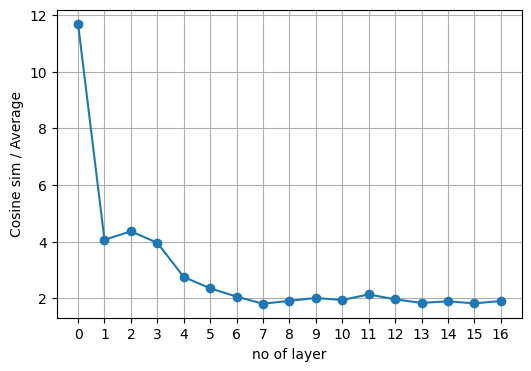

In [ ]:
sentence1 = "I ate an apple for breakfast."
sentence2 = "The company that brought us the iPad and AirPods is apple."

inputs1 = tokenizer.encode(sentence1, return_tensors="pt")
outputs1 = model(inputs1, output_hidden_states=True)
hidden_states1 = outputs1.hidden_states

inputs2 = tokenizer.encode(sentence2, return_tensors="pt")
outputs2 = model(inputs2, output_hidden_states=True)
hidden_states2 = outputs2.hidden_states

distances = []
for l in range(len(hidden_states)):
    layer_hidden_states1 = hidden_states1[l][0].detach().numpy() # Shape: [seq_len1, hidden_size]
    layer_hidden_states2 = hidden_states2[l][0].detach().numpy() # Shape: [seq_len2, hidden_size]
    # Calculate pairwise cosine similarity between all tokens in sentence1 and sentence2 for this layer
    pairwise_sim = cosine_similarity(layer_hidden_states1, layer_hidden_states2) # Shape: [seq_len1, seq_len2]
    avg_sim_layer = pairwise_sim.mean()

    vec1 = hidden_states1[l][0][idx1].detach().numpy()  # Vecteur de '▁apple' dans la phrase 1
    vec2 = hidden_states2[l][0][idx2].detach().numpy()  # Vecteur de '▁apple' dans la phrase 2
    cos_sim = cosine_similarity([vec1], [vec2])[0]

    distances.append(cos_sim/avg_sim_layer)

# Tracer le graphique de la distance en fonction du nombre de couches
layers = list(range(len(distances)))
plt.figure(figsize=(6, 4))
plt.plot(layers, distances, marker='o')
plt.xticks(layers)
plt.xlabel("no of layer")
plt.ylabel("Cosine sim / Average")
plt.grid(True)
plt.show()

In [ ]:
len(hidden_states)

17

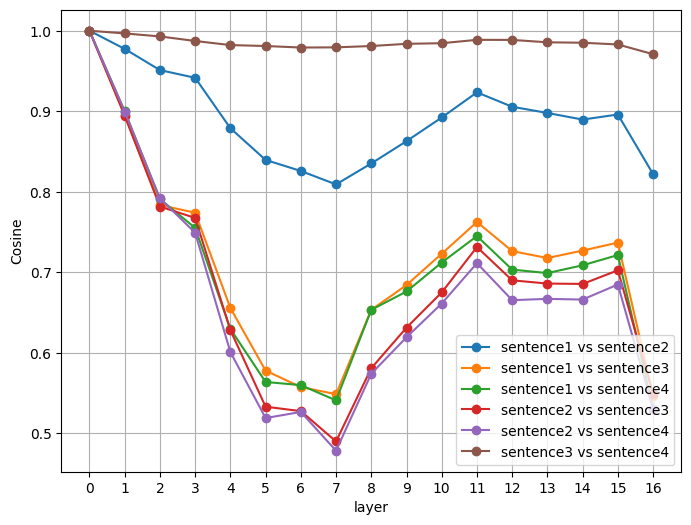

In [ ]:
# Définir 4 phrases : les deux premières sont "pomme comestible", les deux dernières sont "entreprise Apple"
sentences = [
    "I ate an apple for breakfast.",                 # Exemple 1 de pomme comestible
    "She baked an apple pie for dessert.",              # Exemple 2 de pomme comestible
    "The tech giant apple announced its quarterly earnings.",    # Exemple 3 de l'entreprise Apple
    "Last week the tech giant apple revealed its new iPhone."    # Exemple 4 de l'entreprise Apple
]
num_sentences = 4

# Encoder et obtenir les états cachés de toutes les couches
hidden_states_batch = []
for i in range(num_sentences):
  inputs = tokenizer.encode(sentences[i], return_tensors="pt")
  #print(inputs)
  outputs = model(inputs, output_hidden_states=True)
  hidden_states_batch.append(outputs.hidden_states)

# Position de l'index de 'apple' dans chaque phrase
idxs = [4,4,4,6]

# Préparer la structure de stockage de similarité pour chaque paire de phrases
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
sim_dict = {pair: [] for pair in pairs}

# Calculer la similarité Cosinus de chaque paire couche par couche
num_layer = 16
for l in range(num_layer+1):
    for (i, j) in pairs:
        vec_i = hidden_states_batch[i][l][0][idxs[i]].detach().numpy()
        vec_j = hidden_states_batch[j][l][0][idxs[j]].detach().numpy()
        sim = cosine_similarity([vec_i], [vec_j])[0]
        sim_dict[(i, j)].append(sim)

# Tracer la courbe de similarité de chaque paire en fonction du nombre de couches
layers = list(range(len(hidden_states)))  # 0 = couche d'embedding
plt.figure(figsize=(8, 6))
for (i, j), sims in sim_dict.items():
    label = f"sentence{i+1} vs sentence{j+1}"
    plt.plot(layers, sims, marker='o', label=label)

plt.xticks(layers)
plt.xlabel("layer")
plt.ylabel("Cosine")
plt.legend()
plt.grid(True)
plt.show()

## Analyser la représentation avec Logit Lens

Dans l'utilisation typique d'un modèle de langage, les tokens d'entrée subissent des calculs à travers plusieurs couches Transformer, et chaque couche produit un ensemble de représentations. Nous prenons généralement uniquement la représentation de la dernière couche, la convertissons en un espace de la taille du vocabulaire via Unembedding (tête LM) pour obtenir le logit de chaque token, et enfin obtenons la distribution de probabilité du token suivant via softmax. En d'autres termes, nous nous concentrons généralement uniquement sur la « dernière couche de sortie ».

L'idée centrale de Logit Lens est : en fait, nous n'avons pas besoin d'attendre la dernière couche; nous pouvons appliquer le même Unembedding à la représentation de chaque couche pour observer ce que le modèle considérerait comme la sortie la plus probable s'il était « utilisé directement pour prédire le token à ce moment-là ». Cela revient à mettre une « paire de lunettes » sur chaque couche pour observer : vers quels mots le modèle penche-t-il lorsqu'il est dans les couches intermédiaires ? Au fur et à mesure que les couches s'approfondissent, comment le modèle converge-t-il progressivement vers la réponse finale ?

In [ ]:
text = "La météo" # La météo, la météo d'aujourd'hui est vraiment ...

input_ids = tokenizer.encode(text, return_tensors="pt")
outputs = model(input_ids, output_hidden_states=True)
hidden_states = outputs.hidden_states  # Longueur = nombre de couches + 1
print(f"Au total {len(hidden_states)} couches de représentation obtenues (y compris l'embedding de token).")

for l in range(len(hidden_states)):
    # Utiliser l'état caché de cette couche via lm_head pour obtenir les logits
    logits = model.lm_head(hidden_states[l])   # [batch, seq_len, vocab_size]

    # Prendre les logits du dernier token
    last_token_logits = logits[0, -1]  # [vocab_size]

    # Sélectionner le token avec le score le plus élevé
    next_token_id = torch.argmax(last_token_logits)

    # Convertir en mot
    print(f"Layer {l:2d} → {tokenizer.decode(next_token_id)}")

Au total 17 couches de représentation obtenues (y compris l'embedding de token).
Layer  0 → éo
Layer  1 → éo
Layer  2 → éo
Layer  3 → éo
Layer  4 →  weather
Layer  5 →  weather
Layer  6 →  weather
Layer  7 → Weather
Layer  8 → /weather
Layer  9 → Weather
Layer 10 →  forecast
Layer 11 →  forecast
Layer 12 →  weather
Layer 13 →  weather
Layer 14 →  weather
Layer 15 →  en
Layer 16 →  est


## Observer ce que fait l'Attention

In [ ]:
#text  = "how are you"
text = "The apple is green. What color is the apple?"

tokens = tokenizer.tokenize(text,add_special_tokens=True)
inputs = tokenizer.encode(text, return_tensors="pt")
model.config._attn_implementation = "eager"
# Pourquoi avons-nous besoin de cela ? Pour dire au modèle d'utiliser honnêtement le PyTorch ordinaire pour calculer l'attention étape par étape, ne pas utiliser la méthode rapide, afin que les attentions aient un contenu.
outputs = model(inputs, output_attentions=True)


'''
# Vous pouvez changer llama en gemma en remplaçant model -> model2, tokenizer -> tokenizer2 dans les lignes ci-dessus
tokens = tokenizer2.tokenize(text,add_special_tokens=True)
inputs = tokenizer2.encode(text, return_tensors="pt")
model2.config._attn_implementation = "eager"
outputs = model2(inputs, output_attentions=True)
'''

attentions = outputs.attentions
print(f"Il y a au total {len(attentions)} couches")
for i, layer_attn in enumerate(attentions):
    print(f"Layer {i} attention shape: {layer_attn.shape}")

# La forme du tenseur de poids d'attention pour chaque couche est [1, 24, L, L].
# 1 → batch_size (une seule chaîne de texte est entrée à la fois, donc batch_size = 1)
# 24 → num_heads (il y a 24 attentions dans chaque couche, chaque tête a un "mode d'attention" différent, par exemple : certaines se concentrent sur la grammaire, d'autres sur la sémantique.)
# L → seq_len (votre phrase d'entrée est découpée en L tokens après le tokenizer)
# En bref, chaque couche a 24 tableaux de taille L×L, chaque case est un poids d'attention (généralement entre 0 et 1, la somme dans la direction de la ligne ≈ 1)

Il y a au total 16 couches
Layer 0 attention shape: torch.Size([1, 32, 12, 12])
Layer 1 attention shape: torch.Size([1, 32, 12, 12])
Layer 2 attention shape: torch.Size([1, 32, 12, 12])
Layer 3 attention shape: torch.Size([1, 32, 12, 12])
Layer 4 attention shape: torch.Size([1, 32, 12, 12])
Layer 5 attention shape: torch.Size([1, 32, 12, 12])
Layer 6 attention shape: torch.Size([1, 32, 12, 12])
Layer 7 attention shape: torch.Size([1, 32, 12, 12])
Layer 8 attention shape: torch.Size([1, 32, 12, 12])
Layer 9 attention shape: torch.Size([1, 32, 12, 12])
Layer 10 attention shape: torch.Size([1, 32, 12, 12])
Layer 11 attention shape: torch.Size([1, 32, 12, 12])
Layer 12 attention shape: torch.Size([1, 32, 12, 12])
Layer 13 attention shape: torch.Size([1, 32, 12, 12])
Layer 14 attention shape: torch.Size([1, 32, 12, 12])
Layer 15 attention shape: torch.Size([1, 32, 12, 12])


[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.43396091e-01 5.66039495e-02 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.56350720e-01 9.54619423e-02 4.81873825e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.39909017e-01 9.53800082e-02 4.01268899e-02 2.45840680e-02
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.05479121e-01 8.54188949e-03 6.48591816e-02 1.15787156e-01
  2.05332667e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.85093284e-01 3.73585932e-02 7.01392964e-02 8.64393264e-02
  7

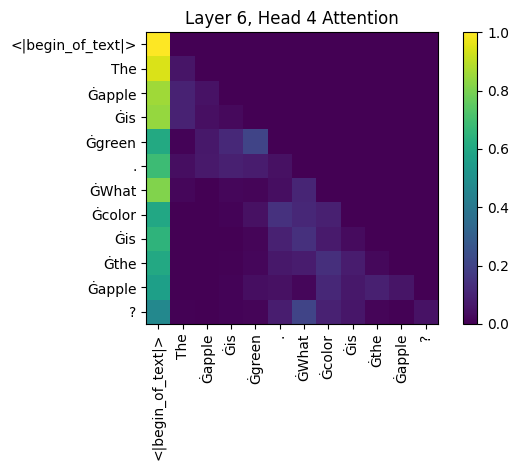

In [ ]:
layer_idx = 5  # Supposons que nous voulions observer la 6ème couche (layer_idx=5)
head_idx = 3  # Supposons que nous voulions observer la 7ème Tête (head_idx=6) # Vous pouvez changer 6 en d'autres nombres, par exemple : 5, 4, 3

attn_matrix = attentions[layer_idx][0][head_idx].detach().numpy()
print(attn_matrix)

import matplotlib.pyplot as plt # Import matplotlib here
plt.imshow(attn_matrix, cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Layer {layer_idx+1}, Head {head_idx+1} Attention")
plt.colorbar()
plt.tight_layout()
plt.show()

# Vous verrez une matrice L X L, essayez d'interpréter ce que vous voyez ? Pourquoi le coin supérieur droit est-il rempli de 0

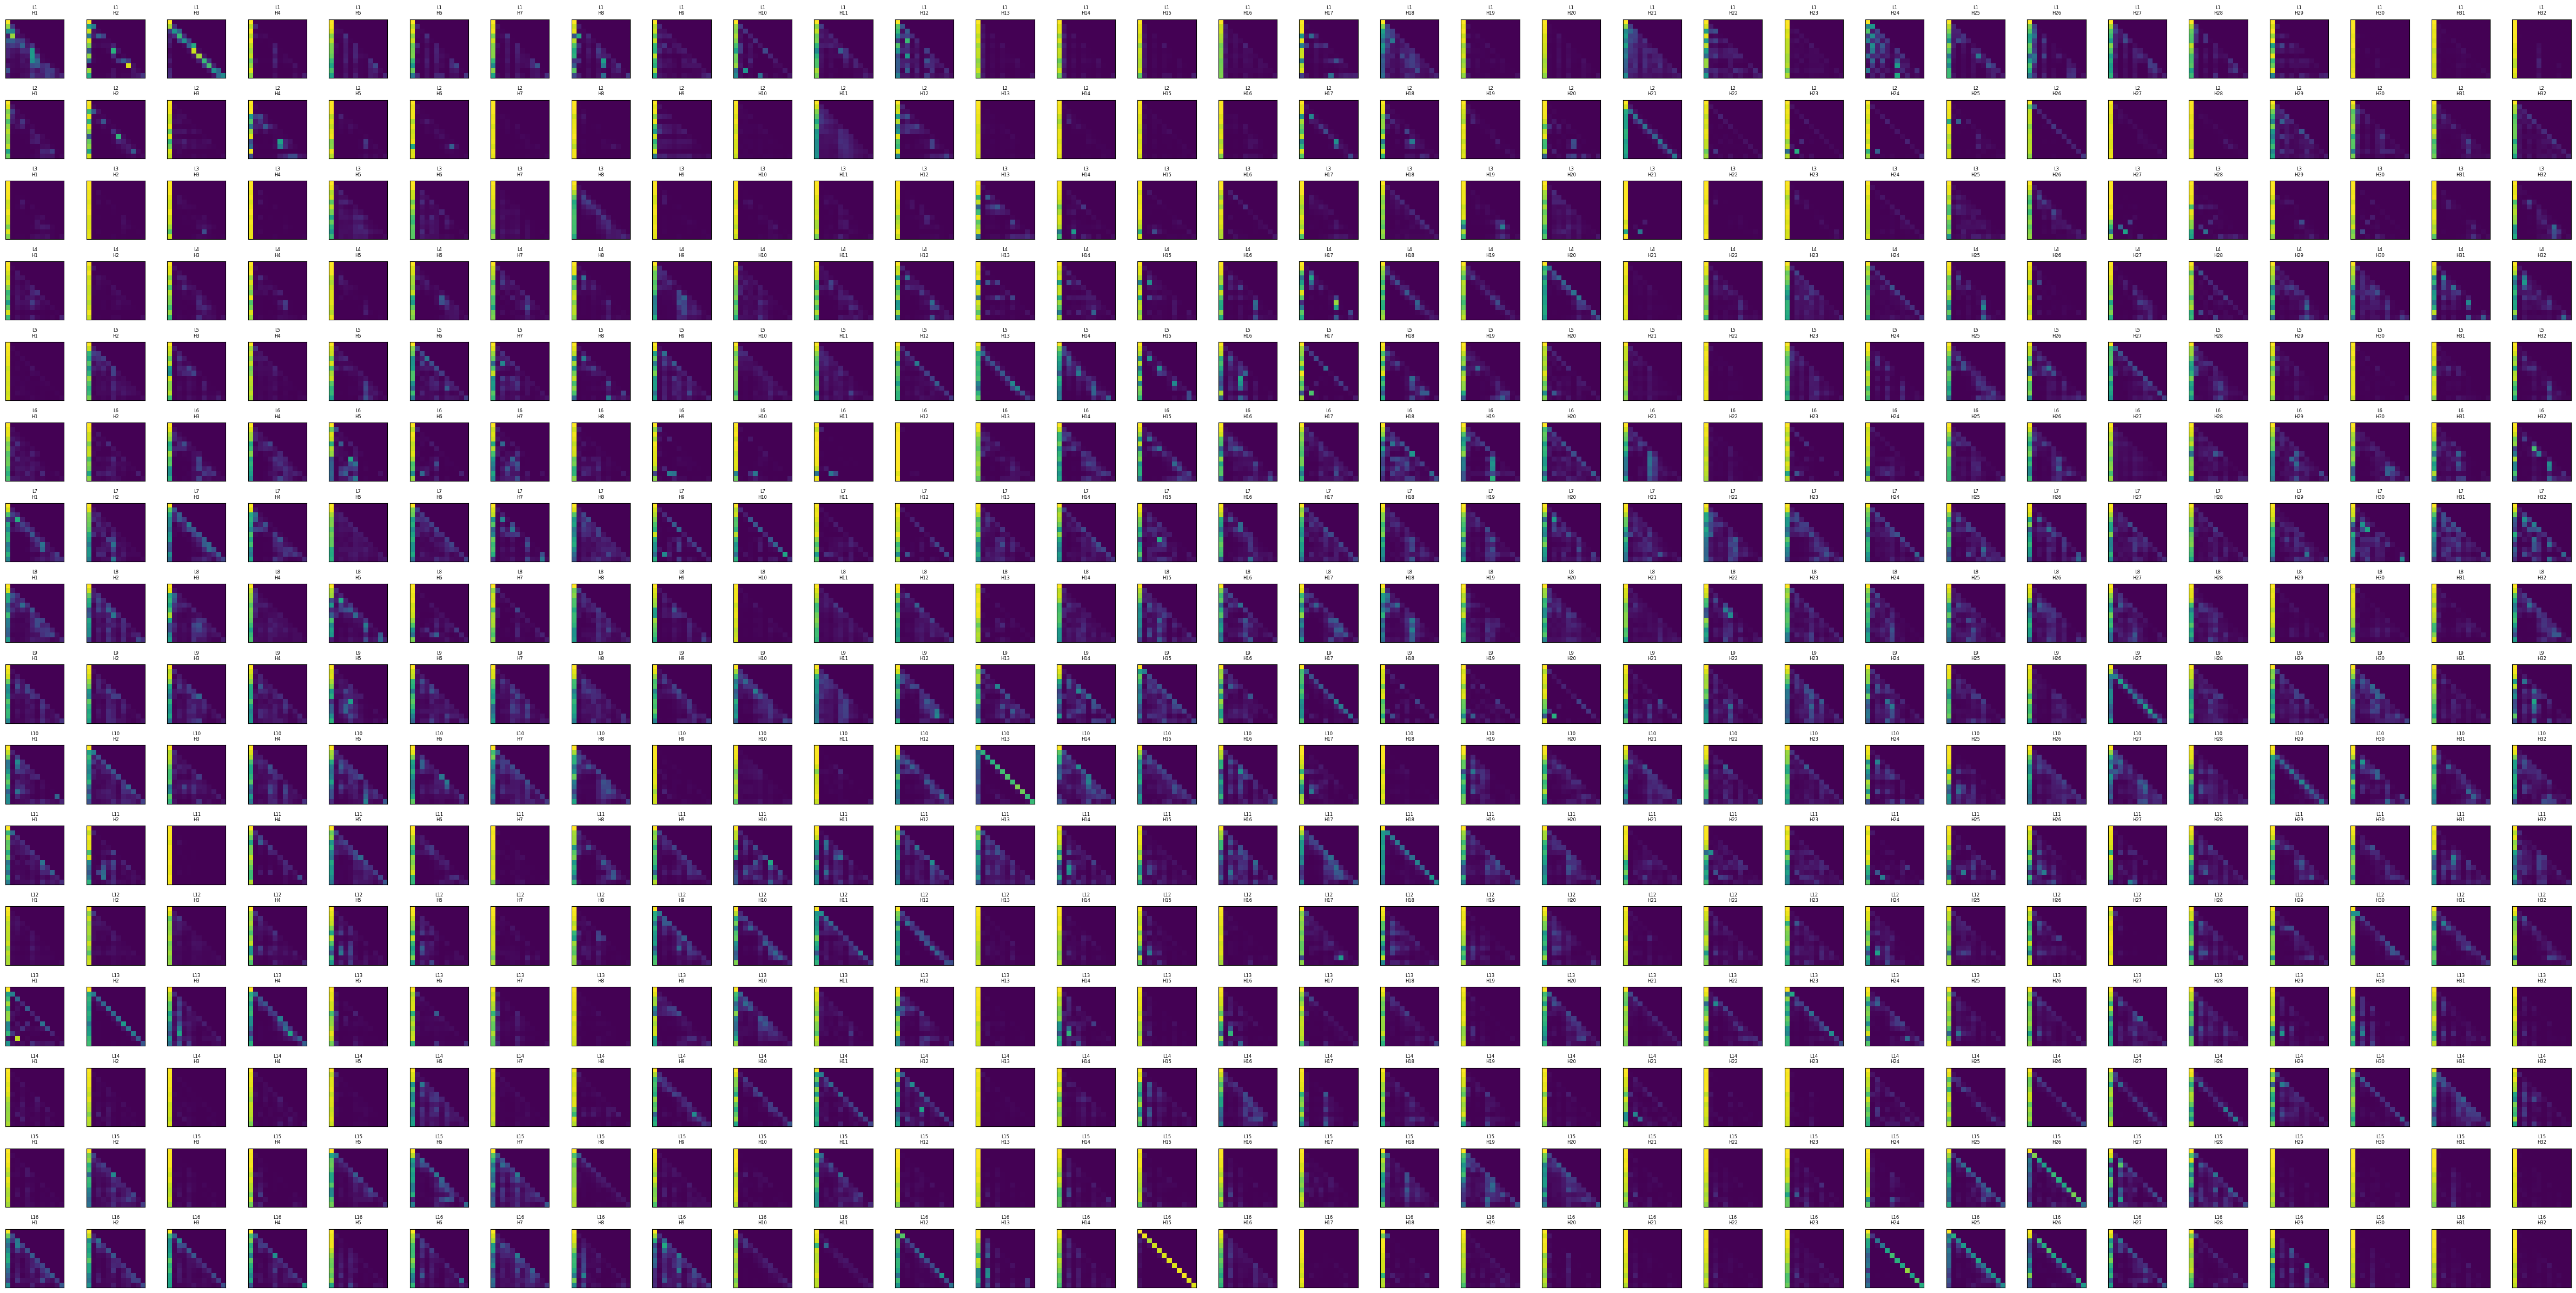

In [ ]:
num_layers = len(attentions)
num_heads = attentions[0].shape[1]  # Nombre de têtes par couche

# Créer le graphique global
fig, axes = plt.subplots(num_layers, num_heads, figsize=(num_heads*1.5, num_layers*1.5))
if num_layers == 1 and num_heads == 1:
    axes = [[axes]]
elif num_layers == 1:
    axes = [axes]
elif num_heads == 1:
    axes = [[ax] for ax in axes]

# Dessiner chaque sous-graphique
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        ax = axes[layer_idx][head_idx]
        attn_matrix = attentions[layer_idx][0, head_idx].detach().cpu().numpy()
        ax.imshow(attn_matrix, cmap="viridis")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"L{layer_idx+1}\nH{head_idx+1}", fontsize=6)

#plt.suptitle("Attention Maps (Layer × Head)", fontsize=14)
plt.tight_layout()
plt.show()

Essayez voir s'il y a un moyen de dessiner l'attention de gemma, et voyez quelles sont les différences ?